In [27]:
import os
import json

import cv2
import torch
from PIL import Image
import numpy as np 
import pandas as pd 
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.patches import Rectangle
from tqdm import tqdm
import wandb
from datetime import datetime

import tonic
import snntorch as snn
from snntorch import surrogate
import snntorch.functional as SF

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchinfo import summary
import torch.nn.functional as F


# clean gpu memory when starting a new evaluation.
torch.cuda.empty_cache()

GPU_DEVICE = 3
os.environ['CUDA_VISIBLE_DEVICES'] = str(GPU_DEVICE)
os.environ['CUDA_LAUNCH_BLOCKING'] = str(1)

assert torch.cuda.is_available()

DEVICE = torch.device(f"cuda") if torch.cuda.is_available() else torch.device("cpu")
assert DEVICE == torch.device(f"cuda"), f'{DEVICE}'

In [2]:
def seed_everything(seed=42):
    #random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    #torch.backends.cudnn.deterministic = True
    #torch.backends.cudnn.benchmark = False
    #os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to {seed}")
    

def create_gif(images, output_gif_path, duration=100):
    if images.shape[-1] == 3:
        images = [Image.fromarray(img) for img in images]
    else:
        images = [Image.fromarray(np.stack([img, img, img], axis=-1)) for img in images]
    # Save as GIF
    images[0].save(output_gif_path,
                    save_all=True,
                    append_images=images[1:],
                    duration=duration,
                    loop=0)

In [3]:
DATA_PATH = 'data/events_converted_from_3D_models/'
DATA_PATH = 'data/recorded_DVS_data_with_ROI/'
event_lst = sorted([f for f in os.listdir(DATA_PATH) if '.npy' in f or '.npz' in f])
W, H      = 346, 260 
CLASS_LST = ['mug', 'bottle', 'coffee_cup']
TEST_LST = ['wild_exploration_robot']

# create data frame
all_samples = []

for obj in TEST_LST:
    path = os.path.join(DATA_PATH, obj)
    event_lst = sorted([f for f in os.listdir(path) if '.npy' in f or '.npz' in f])
    print(len(event_lst))
    
    for i, file in enumerate(event_lst):
        file_path = os.path.join(DATA_PATH, obj, file)
        data = np.load(file_path, allow_pickle=True) 
        cx = int(data["cx"].item()) #x coordinate of ROI center
        cy = int(data["cy"].item()) #y coordinate of ROI center
        roi_size = int(data["roi_size"].item()) 
        
        all_samples.append({'label': obj, 'id': i, 'roi_cx': cx, 'roi_cy': cy, 
                            'roi_size': roi_size, 'file': file})

df = pd.DataFrame.from_records(all_samples)
df['category'] = df.apply(lambda x: TEST_LST.index(x['label']), axis=1)
df.head()

652


,label,id,roi_cx,roi_cy,roi_size,file,category
0,wild_exploration_robot,0,125,146,156,exploration_robot_00002_full.npz,0
1,wild_exploration_robot,1,125,101,154,exploration_robot_00003_full.npz,0
2,wild_exploration_robot,2,125,142,159,exploration_robot_00004_full.npz,0
3,wild_exploration_robot,3,131,135,137,exploration_robot_00005_full.npz,0
4,wild_exploration_robot,4,118,126,114,exploration_robot_00014_full.npz,0


wild_exploration_robot 0 torch.Size([35, 48, 48])


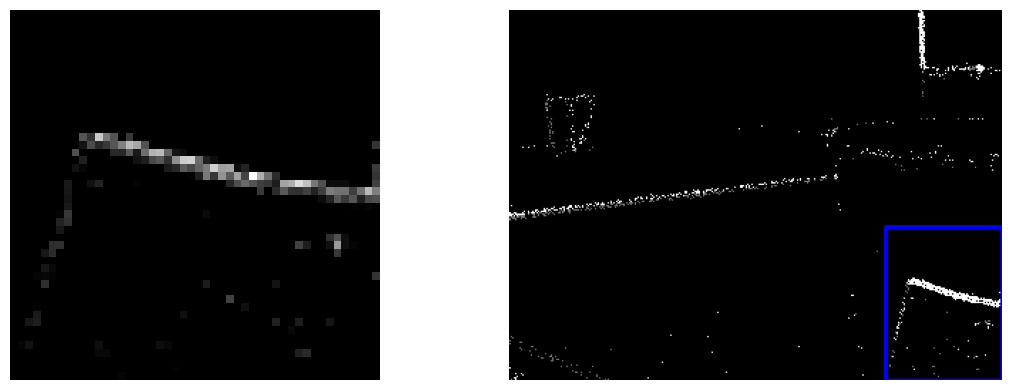

In [63]:
class DVSDataset(Dataset):
    """Custom DVS dataset for RoDeO
    """

    def __init__(self, dataset, data_path, frame_size=(260, 346), target_size=(48, 48),
                 time_bins=35, use_roi=False, create_img=False, transform=None):
        
        self.data_path = data_path
        self.dataset = dataset
        self.create_img = create_img
        self.frame_size = frame_size
        self.time_bins = time_bins
        self.use_roi = use_roi
        fsize = np.max(frame_size).astype(int)
        self.tonic_transform = tonic.transforms.Compose([#tonic.transforms.Denoise(filter_time=10000), 
                                                         #tonic.transforms.MergePolarities(),
                                                         tonic.transforms.Downsample(sensor_size=(346, 346, 1), target_size=target_size),
                                                         tonic.transforms.ToFrame(sensor_size=(*target_size, 1), n_time_bins=time_bins)])
        self.toframe =  tonic.transforms.ToFrame(sensor_size=(*frame_size[::-1], 1), n_time_bins=time_bins)
        self.transform = transform
        
        
    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        
        label = self.dataset.iloc[idx].label
        file = self.dataset.iloc[idx].file 
        cat = self.dataset.iloc[idx].category
        fpath = os.path.join(self.data_path, label+'/', file)
        
        # Load data 
        data = np.load(fpath, allow_pickle=True) 
        events = data["events"].item() if data["events"].ndim == 0 else data["events"] 
        xs = events["x"].astype(np.int32) #x coordinates of events
        ys = events["y"].astype(np.int32) #y coordinates of events
        pol = np.where(events["polarity"], events["polarity"], 1).astype('i1') # turn all polarities to positive
        t = events["timestamp"].astype(np.int64)
        
        # clip to frame size
        mask = (xs >= 0) & (xs < self.frame_size[1]) & (ys >= 0) & (ys < self.frame_size[0]) 
        
        # Stack into a structured array for tonic
        stack_events = np.rec.fromarrays([xs[mask], ys[mask], pol, t], dtype=[('x', '<i2'), ('y', '<i2'), ('p', 'i1'), ('t', '<i8')])
        
        if self.use_roi: 
            roi_cx, roi_cy = self.dataset.iloc[idx].roi_cx, self.dataset.iloc[idx].roi_cy
            roi_size = self.dataset.iloc[idx].roi_size
            y_start, y_end, x_start, x_end = roi_cy-roi_size//2, roi_cy+roi_size//2, roi_cx-roi_size//2, roi_cx+roi_size//2
            y_start, y_end = np.clip(y_start, 0, frame_size[0]), np.clip(y_end, 0, frame_size[0])
            x_start, x_end = np.clip(x_start, 0, frame_size[1]), np.clip(x_end, 0, frame_size[1])
            frame = self.toframe(stack_events)
            frame = frame[:, :, y_start: y_end,  x_start: x_end]
            frame = F.interpolate(torch.tensor(frame).float(), size=(48, 48), mode='bilinear', align_corners=False)
            frame = frame.squeeze()
        else:
            # turn events into frames with tonic 
            frame = self.tonic_transform(stack_events)
            frame = np.moveaxis(frame.squeeze(), 0, -1) # reshape frame for torchvision transforms

            if self.transform: 
                frame = self.transform(frame)
        
        img = None
        if self.create_img:  
            pol = events["polarity"].astype(bool) 
            img = np.zeros((*self.frame_size, 3), dtype=np.uint8)
            img[ys[mask &  pol], xs[mask &  pol]] = (255, 255, 255)   # positive: white
            img[ys[mask & ~pol], xs[mask & ~pol]] = (120, 120, 120)   # negative: grey
            
            if self.use_roi:
                cv2.rectangle(img, (x_start, y_start), (x_end, y_end), (0, 0, 255), thickness=2)
            
        return {'img': img, 'frame': frame, 'cat': int(cat), 'label': label, 'file': file, 'path': fpath}


dataset = DVSDataset(df, DATA_PATH, transform=transforms.ToTensor(), create_img=True, use_roi=True)
sample = dataset.__getitem__(300)
print(sample['label'], sample['cat'], sample['frame'].shape)

# plot frame and origin input 
f, (ax1, ax2) = plt.subplots(1, 2, sharey=False, figsize=(12, 4))
ax1.imshow(sample['frame'].sum(axis=0), cmap='gray')
ax1.axis('off')

ax2.imshow(sample['img'])
ax2.axis('off')

f.tight_layout()
plt.show()

186
(35, 260, 346)


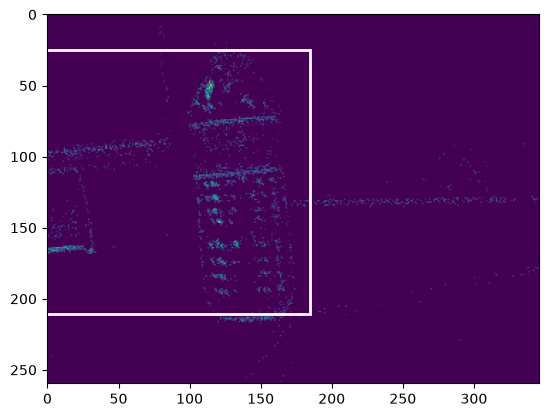

0 185 25 211
(35, 186, 185)
torch.Size([35, 1, 48, 48])


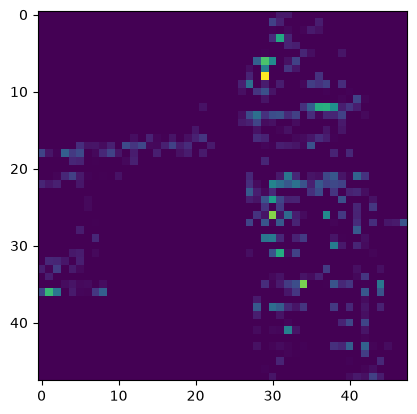

In [46]:
from matplotlib.patches import Rectangle

frame_size = (260, 346)
idx = 20
temp_df = df.iloc[idx]
label = temp_df.label
file = temp_df.file 
cat = temp_df.category
fpath = os.path.join(DATA_PATH, label+'/', file)

# Load data 
data = np.load(fpath, allow_pickle=True) 
events = data["events"].item() if data["events"].ndim == 0 else data["events"] 
xs = events["x"].astype(np.int32) #x coordinates of events
ys = events["y"].astype(np.int32) #y coordinates of events
pol = np.where(events["polarity"], events["polarity"], 1).astype('i1') # turn all polarities to positive
t = events["timestamp"].astype(np.int64)

# clip to frame size
mask = (xs >= 0) & (xs < frame_size[1]) & (ys >= 0) & (ys < frame_size[0]) 

roi_cx, roi_cy = temp_df.roi_cx, temp_df.roi_cy
roi_size = temp_df.roi_size
print(roi_size)

T = tonic.transforms.ToFrame(sensor_size=(*frame_size[::-1], 1), n_time_bins=35)

# Stack into a structured array for tonic
stack_events = np.rec.fromarrays([xs[mask], ys[mask], pol, t], dtype=[('x', '<i2'), ('y', '<i2'), ('p', 'i1'), ('t', '<i8')])
frame = T(stack_events).squeeze()
print(frame.shape)

plt.imshow(frame.mean(0).squeeze())

rect = Rectangle((roi_cy - roi_size//2, roi_cx - roi_size//2), roi_size, roi_size, linewidth=2, edgecolor='w', facecolor='none')
ax = plt.gca()
ax.add_patch(rect)
#plt.axis('off')
plt.show()

y_start, y_end, x_start, x_end = roi_cy-roi_size//2, roi_cy+roi_size//2, roi_cx-roi_size//2, roi_cx+roi_size//2
y_start, y_end = np.clip(y_start, 0, frame_size[0]), np.clip(y_end, 0, frame_size[0])
x_start, x_end = np.clip(x_start, 0, frame_size[1]), np.clip(x_end, 0, frame_size[1])

print(y_start, y_end, x_start, x_end)

frame = frame[:, x_start: x_end, y_start: y_end]
print(frame.shape)

plt.imshow(frame.mean(0))


frame = F.interpolate(torch.tensor(frame).float().unsqueeze(1), size=(48, 48), mode='bilinear', align_corners=False)
print(frame.shape)

plt.imshow(frame.mean(0).squeeze())

In [58]:
frames = sample['frame'].numpy() * 255
create_gif(frames.astype(np.uint8), f'bottle.gif') 

In [35]:
train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.95), len(dataset) - int(len(dataset) * 0.95)])
print('Training samples: ',len(train_set))
print('Validation samples: ', len(val_set))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=16)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=8)

Training samples:  760
Validation samples:  40


## Define Model 

In [54]:
class SpikingObjectClassifier(nn.Module):
    
    def __init__(self, in_channels=1, img_size=(48, 48), hidden=[1, 2, 3],
                 hidden_channels=4, kernel=3, stride=1, padding=1,
                 spike_grad=surrogate.atan(), beta=0.95, num_steps=35, lif_threshold=0.5,
                 n_classes=257, dropout=None):
        super().__init__()
        
        self.num_steps = num_steps
        self.dropout = True if dropout else False
        
        self.conv1 = nn.Conv2d(1, hidden_channels*hidden[0], kernel, stride, padding, bias=False)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.conv2 = nn.Conv2d(hidden_channels*hidden[0], hidden_channels*hidden[1], 
                               kernel, stride*hidden[2], padding, bias=False)
        
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.conv3 = nn.Conv2d(hidden_channels*hidden[1], hidden_channels*hidden[2], 
                               kernel, stride*hidden[2], padding, bias=False)
        
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                              learn_threshold=True, learn_beta=False)
        
        self.pool = nn.AvgPool2d(kernel_size=2) # maxpooling is unsuitable for SNNs
        
        # use dropout as regularization 
        self.dropout1 = nn.Dropout(p=dropout) if dropout else None
        self.dropout2 = nn.Dropout(p=dropout) if dropout else None
        self.dropout_linear = nn.Dropout(p=dropout) if dropout else None
        self.dropout_out = nn.Dropout(p=dropout) if dropout else None

            
        # flatten before linear layer
        self.fc = nn.Flatten()
        
        hidden_dim = self._get_hidden_dim(torch.ones(1, num_steps, *img_size))
        
        # define classifier
        
        self.classifier = nn.Linear(hidden_dim, n_classes, bias=False)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, threshold=lif_threshold, 
                                 learn_threshold=True, learn_beta=False)
        
        #self._initialize_weights()
        
    def _get_hidden_dim(self, x):
        cur1 = self.conv1(x[:, 0].unsqueeze(1))
        cur2 = self.conv2(cur1)
        cur3 = self.conv3(cur2)
        out = self.fc(cur3)
        return out.shape[-1]
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight, gain=1.0)
    
    def forward(self, x):
        B, T, H, W = x.shape
        
        # Initialize hidden states and outputs at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem_out = self.lif_out.init_leaky()
        
        fmap1_rec = []
        fmap2_rec = []
        fmap3_rec = []
        
        spk_out_rec = []
        mem_out_rec = []
        for step in range(T):
            
            # conv layer 1
            #print(x[:, step].unsqueeze(1).shape)
            cur1 = self.conv1(x[:, step].unsqueeze(1))
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1) if self.dropout else spk1
            fmap1_rec.append(spk1)
            
            # conv layer 2
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.dropout2(spk2) if self.dropout else spk2
            fmap2_rec.append(spk2)
            
            # conv layer 3
            cur3 = self.conv3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            fmap3_rec.append(spk3)
            
            # classifier
            spk_out = self.fc(spk3)
            spk_out = self.classifier(spk_out)
            spk_out, mem_out = self.lif_out(spk_out, mem_out)
            spk_out = self.dropout_out(spk_out) if self.dropout else spk_out
            
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)
        
        return torch.stack(spk_out_rec, dim=0), torch.stack(mem_out_rec, dim=0), [torch.stack(fmap1_rec, dim=0), torch.stack(fmap2_rec, dim=0), torch.stack(fmap3_rec, dim=0)]

In [55]:
model = SpikingObjectClassifier(img_size=(48, 48), n_classes=257, hidden_channels=4)
summary(model, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SpikingObjectClassifier                  [1, 1, 257]               --
├─Conv2d: 1-1                            [1, 4, 48, 48]            36
├─Leaky: 1-2                             [1, 4, 48, 48]            1
├─Conv2d: 1-3                            [1, 8, 16, 16]            288
├─Leaky: 1-4                             [1, 8, 16, 16]            1
├─Conv2d: 1-5                            [1, 12, 6, 6]             864
├─Leaky: 1-6                             [1, 12, 6, 6]             1
├─Flatten: 1-7                           [1, 432]                  --
├─Linear: 1-8                            [1, 257]                  111,024
├─Leaky: 1-9                             [1, 257]                  1
Total params: 112,216
Trainable params: 112,216
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.30
Input size (MB): 0.01
Forward/backward pass size (MB): 0.19
Params size (MB): 0.45
Estimated Total Size (MB): 

## Load Pretrained

In [56]:
DROPOUT = 0.2
BETA = 0.97
LIF_THRESHOLD = 0.3
ALPHA = 0.5
SURROGATE = 'atan'
HIDDEN_CHANNELS = 4

with open('caltech256_classes.json', 'r') as file:
    caltech256_classes = json.load(file)

pretrained_path = 'results/Spiking-RoDeO_257_7_25Jun26-195451.pth'
finetuned_path = 'results/Spiking-RoDeO-Finetuned_5_7_25Jun26-194420.pth'

spike_grad = surrogate.fast_sigmoid(slope=25) if SURROGATE == 'fast_sigmoid' else surrogate.atan()

model = SpikingObjectClassifier(img_size=(48,48), n_classes=5, hidden_channels=HIDDEN_CHANNELS, beta=BETA,
                                spike_grad=spike_grad, dropout=DROPOUT, lif_threshold=LIF_THRESHOLD)

weights = torch.load(finetuned_path, weights_only=True)

model.load_state_dict(weights, strict=False)
model.to(DEVICE)
model.eval()

SpikingObjectClassifier(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (lif1): Leaky()
  (conv2): Conv2d(4, 8, kernel_size=(3, 3), stride=(3, 3), padding=(1, 1), bias=False)
  (lif2): Leaky()
  (conv3): Conv2d(8, 12, kernel_size=(3, 3), stride=(3, 3), padding=(1, 1), bias=False)
  (lif3): Leaky()
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (dropout1): Dropout(p=0.2, inplace=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (dropout_linear): Dropout(p=0.2, inplace=False)
  (dropout_out): Dropout(p=0.2, inplace=False)
  (fc): Flatten(start_dim=1, end_dim=-1)
  (classifier): Linear(in_features=432, out_features=5, bias=False)
  (lif_out): Leaky()
)

In [57]:
summary(model, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SpikingObjectClassifier                  [1, 1, 5]                 --
├─Conv2d: 1-1                            [1, 4, 48, 48]            36
├─Leaky: 1-2                             [1, 4, 48, 48]            1
├─Dropout: 1-3                           [1, 4, 48, 48]            --
├─Conv2d: 1-4                            [1, 8, 16, 16]            288
├─Leaky: 1-5                             [1, 8, 16, 16]            1
├─Dropout: 1-6                           [1, 8, 16, 16]            --
├─Conv2d: 1-7                            [1, 12, 6, 6]             864
├─Leaky: 1-8                             [1, 12, 6, 6]             1
├─Flatten: 1-9                           [1, 432]                  --
├─Linear: 1-10                           [1, 5]                    2,160
├─Leaky: 1-11                            [1, 5]                    1
├─Dropout: 1-12                          [1, 5]                    --
Total params: 

In [75]:
test_loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=8)
CLASS_LST = ['mug', 'bottle', 'cup', 'banana', 'apple']

all_imgs = []
for i, batch in enumerate(test_loader):
    
    # get batched data
    B, T, H, W = batch['frame'].shape
    frames = batch['frame'].float().to(DEVICE)
    

    spk_out, mem_rec, fmaps = model(frames)
    logits = spk_out.sum(0) # [B,C]
    
    pred = logits.argmax()
    
    img = batch['img'].squeeze()
    #print(img.shape, pred)
    """
    img = batch['frame'].float().squeeze().mean(0)
    img = img.detach().cpu().numpy() * 255
    #img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    img = np.stack([img, img, img], axis=-1)
    """
    
    img = cv2.putText(img.numpy(), 'Predicted: ' + CLASS_LST[pred], (5, 250), 
                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 225), 1, lineType=cv2.LINE_AA)
    
    all_imgs.append(img)


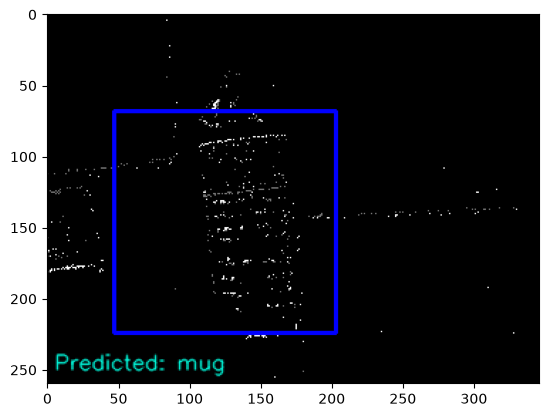

In [76]:
plt.imshow(np.stack(all_imgs).astype(np.uint8)[0])

In [77]:
create_gif(np.stack(all_imgs).astype(np.uint8), f'predicted.gif') 

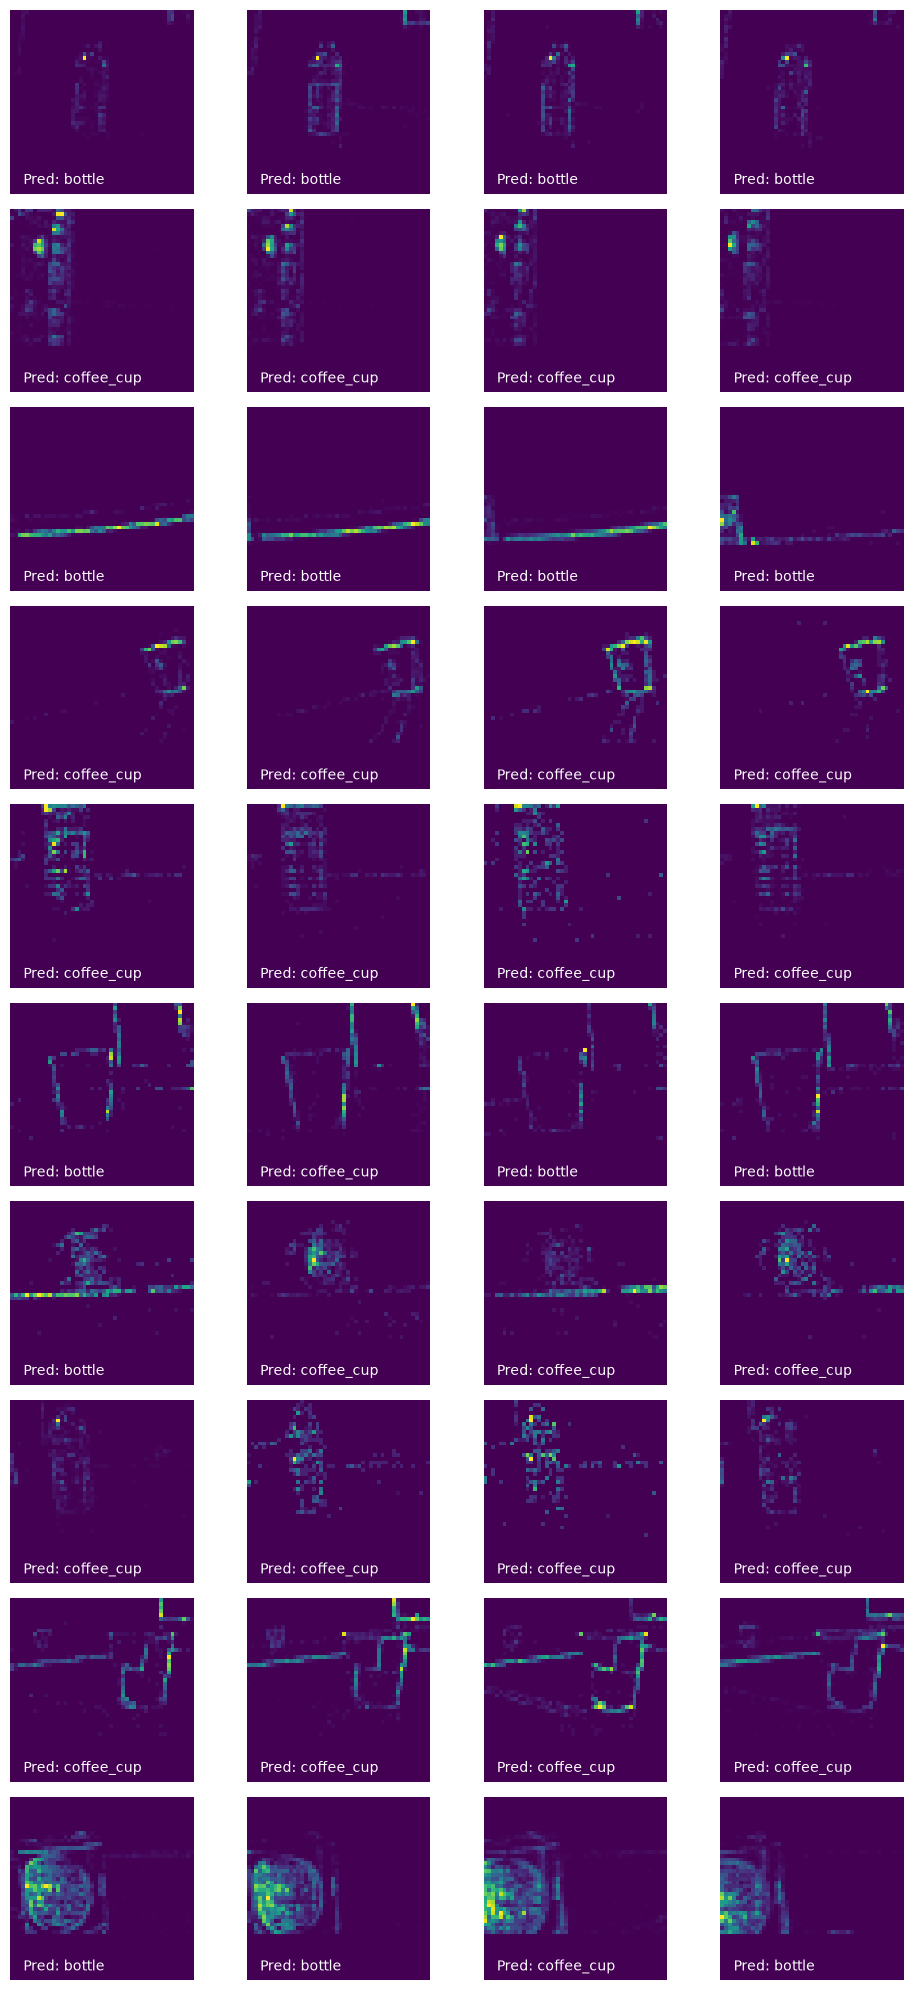

In [48]:
model.eval()
CLASS_LST = ['mug', 'bottle', 'coffee_cup', 'banana', 'apple']

fig, axs = plt.subplots(10, 4, figsize=(10, 20))

n = 25
for i, batch in enumerate(test_loader):
    if i % n == 0:
    
        # get batched data
        B, T, H, W = batch['frame'].shape
        frames = batch['frame'].float().to(DEVICE)

        spk_out, mem_rec, fmaps = model(frames)
        logits = spk_out.sum(0) # [B,C]
        
        for idx in range(0, 8, 2):
            
            pred = logits[idx].argmax()
            
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i // n, idx // 2].imshow(batch['frame'].float()[idx].mean(0))
            axs[i // n, idx // 2].axis('off')
            axs[i // n, idx // 2].text(3, 45, 'Pred: ' + CLASS_LST[pred], color="white", fontsize=10)
        
plt.tight_layout()
plt.show()




In [ ]:
"""
# get batched data
B, T, H, W = batch['frame'].shape
frames = batch['frame'].float().to(DEVICE)
#cats = batch['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

for idx in range(len(sample['label'])):
    
    label = sample['label'][idx]

    plt.imshow(batch['frame'].float()[idx].mean(0))
    
    pred = spk_out.sum(dim=0)[idx].argmax()
    print('Predicted: ', CLASS_LST[pred])
    # Syntax: plt.text(x, y, "Your Text")
    plt.text(3, 45, 'Predicted: ' + CLASS_LST[pred], color="white", fontsize=20)
    plt.axis('off')
    plt.show()
    



all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.mean(torch.stack(cur_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.sum(torch.stack(mem_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    counter += 1
        
plt.axis('off')
plt.tight_layout()
plt.show()


if len(fmaps) > 1:
    
    print(fmaps[1].shape, torch.where(fmaps[1].mean(dim=0).view(256, -1).argmax()))
    
    all_feature_maps = fmaps[1].sum(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

pred = spk_out.sum(dim=0)[idx].argmax()
#print(pred, caltech256_classes[pred], cats[idx])
"""

### Replace final layer for finetuning

In [88]:
# Freeze all layers 
for param in model.parameters():
    param.requires_grad = False

old_in_features = model.classifier.in_features
new_num_classes = 5 

# Replace the output layer
model.classifier = nn.Linear(old_in_features, new_num_classes, bias=False)

# Only unfreeze the new layer 
for param in model.fc.parameters():
    param.requires_grad = True
    
summary(model, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SpikingObjectClassifier                  [1, 1, 5]                 --
├─Conv2d: 1-1                            [1, 4, 48, 48]            (36)
├─Leaky: 1-2                             [1, 4, 48, 48]            (1)
├─Dropout: 1-3                           [1, 4, 48, 48]            --
├─Conv2d: 1-4                            [1, 8, 16, 16]            (288)
├─Leaky: 1-5                             [1, 8, 16, 16]            (1)
├─Dropout: 1-6                           [1, 8, 16, 16]            --
├─Conv2d: 1-7                            [1, 12, 6, 6]             (864)
├─Leaky: 1-8                             [1, 12, 6, 6]             (1)
├─Flatten: 1-9                           [1, 432]                  --
├─Linear: 1-10                           [1, 5]                    2,160
├─Leaky: 1-11                            [1, 5]                    (1)
├─Dropout: 1-12                          [1, 5]                    --


In [94]:
DEBUG = False
RANDOM_SEED = 7
seed_everything(RANDOM_SEED)

LR = 0.001
EPOCHS = 50
BATCH_SIZE = 512
DROPOUT = 0.2
BETA = 0.97
LIF_THRESHOLD = 0.3
OPTIMIZER = 'AdamW'
SURROGATE = 'atan'
HIDDEN_CHANNELS = 4
PRETRAINED = True

train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.95), len(dataset) - int(len(dataset) * 0.95)])
print('Training samples: ',len(train_set))
print('Validation samples: ', len(val_set))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, num_workers=16)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=8)
N_CLASSES = 5
print('Number of classes: ', N_CLASSES)

x = datetime.now()
TIME_STAMP = x.strftime("%d%b%y-%H%M%S")
pt = 'PT_' if PRETRAINED else ''
MODEL_NAME = f"Spiking-RoDeO-Finetuned_{pt}{N_CLASSES}_{RANDOM_SEED}_{TIME_STAMP}"
print(MODEL_NAME)

spike_grad = surrogate.fast_sigmoid(slope=25) if SURROGATE == 'fast_sigmoid' else surrogate.atan()

if not DEBUG:
    # Initialize wandb 
    wandb.init(project='RoDeO',
               name=MODEL_NAME,
               config={'optimizer': OPTIMIZER, 
                       'lr': LR,
                       'pretrained': PRETRAINED,
                       'hidden_channels': HIDDEN_CHANNELS,
                       'n_classes': N_CLASSES,
                       'lif_threshold': LIF_THRESHOLD,
                       'dropout': DROPOUT,
                       'beta': BETA,
                       'surrogate': SURROGATE,
                       'loss': 'CrossEntropy',
                       'epochs': EPOCHS,
                       'batch_size': BATCH_SIZE})


if PRETRAINED: 
    # Load pretrained model
    pretrained_path = 'results/Spiking-RoDeO_257_7_25Jun26-195451.pth'

    model = SpikingObjectClassifier(img_size=(48,48), n_classes=257, hidden_channels=HIDDEN_CHANNELS, beta=BETA,
                                    spike_grad=spike_grad, dropout=DROPOUT, lif_threshold=LIF_THRESHOLD)

    weights = torch.load(pretrained_path, weights_only=True)
    model.load_state_dict(weights)

    # Freeze all layers 
    for param in model.parameters():
        param.requires_grad = False

    # Replace the output layer
    model.classifier = nn.Linear(model.classifier.in_features, N_CLASSES)

    # Unfreeze the new layer 
    for param in model.classifier.parameters():
        param.requires_grad = True
else:
    print('Creating new model')
    model = SpikingObjectClassifier(img_size=(48,48), n_classes=N_CLASSES, hidden_channels=HIDDEN_CHANNELS, beta=BETA,
                                    spike_grad=spike_grad, dropout=DROPOUT, lif_threshold=LIF_THRESHOLD)

model.to(DEVICE)

# initialize loss function & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = getattr(torch.optim, OPTIMIZER)(model.parameters(), lr=LR)

best_val_acc = 0.5
outpath = f'results/{MODEL_NAME}.pth'
for epoch in range(EPOCHS):
    
    train_loss = []
    train_accuracy = []
    train_grad_norms = []
    
    model.train()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}', unit='batch', ncols=115)
    for i, sample in enumerate(pbar):
        
        #nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.zero_grad()
        
        B, T, H, W = sample['frame'].shape
        frames = sample['frame'].float().view(B, T, H, W).to(DEVICE)
        cats = sample['cat'].to(DEVICE) 

        spk_out, mem_rec, _ = model(frames)
        
        logits = spk_out.sum(0) # [B,C]
        probs = torch.softmax(logits, dim=1)
        loss = loss_fn(probs, cats)
        
        loss.backward()
        
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        train_grad_norms.append(total_norm)
        
        optimizer.step()
        
        # log train loss 
        train_loss.append(loss.item())
        
        # compute train accuracy
        preds = logits.argmax(dim=1)
        acc = (preds == cats).sum().item()
        train_accuracy.append(acc / B)
        
        pbar.set_postfix(loss=f'{loss.item():.3f}', acc=f'{acc / B:.2%}')
    
    #pbar.set_postfix({'avg_loss':f'{np.mean(train_loss):.3f}', 'avg_acc':f'{np.mean(train_accuracy):.2%}'})
    print(f'Average training loss: {np.mean(train_loss):.2f} - accuracy {np.mean(train_accuracy):.2%}')
    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    
    # log results / gradients / weights to wandb
    if not DEBUG:
        log_layers = ['conv1.weight', 'conv2.weight', 'classifier.weight']
        
        # only log once per epoch for faster training
        log_dict = {'loss': np.mean(train_loss), 'accuracy': np.mean(train_accuracy), 
                    'gradient/total_norm': np.mean(train_grad_norms), 'epoch': epoch}
        
        for name, param in model.named_parameters():
            if param.grad is not None:
                log_dict[f'gradient/{name}_norm'] = param.grad.norm().item()
                
            if name in log_layers:
                log_dict[f'weights/{name.split(".")[0]}'] = wandb.Histogram(param.detach().cpu().numpy())
        
        wandb.log(log_dict)    
    
    # Validation
    model.eval()
    val_loss = []
    val_accuracy = []
    with torch.no_grad():
        for i, sample  in enumerate(val_loader):
            B, T, H, W = sample['frame'].shape
            frames = sample['frame'].float().to(DEVICE)
            cats = sample['cat'].to(DEVICE) 

            spk_out, mem_rec, _ = model(frames)
            
            # compute loss
            """
            loss = loss_fn(spk_out, cats)
            logits = spk_out.sum(0) # [B,C]
            """
            
            logits = spk_out.sum(0) # [B,C]
            probs = torch.softmax(logits, dim=1)
            loss = loss_fn(probs, cats)
        
            val_loss.append(loss.item())
            
            # compute validation accuracy
            preds = logits.argmax(dim=1)
            acc = (preds == cats).sum().item()
            val_accuracy.append(acc / B)
            
    print(f'validation loss: {np.mean(val_loss):.2f} - accuracy {np.mean(val_accuracy):.2%}')
    if not DEBUG:
        # log validation metrics to wandb
        wandb.log({'val_loss': np.mean(val_loss), 'val_accuracy': np.mean(val_accuracy), 'epoch': epoch}) 
    
        # save best model
        if np.mean(val_accuracy) > best_val_acc:
            best_val_acc = np.mean(val_accuracy)
            torch.save(model.state_dict(), best_model_path)
            print('Saved model to:', outpath)
        
        
if not DEBUG:
    wandb.finish() 

Global seed set to 7
Training samples:  760
Validation samples:  40
Number of classes:  5
Spiking-RoDeO-Finetuned_PT_5_7_26Jun26-003358


Epoch 0: 100%|██████████████████████████████████████████| 12/12 [00:01<00:00,  7.06batch/s, acc=46.43%, loss=1.429]

Average training loss: 1.46 - accuracy 42.80%
Current LR: 0.001


validation loss: 1.32 - accuracy 58.33%
Saved model to: results/Spiking-RoDeO-Finetuned_PT_5_7_26Jun26-003358.pth


Epoch 1: 100%|██████████████████████████████████████████| 12/12 [00:01<00:00,  7.02batch/s, acc=53.57%, loss=1.345]

...

validation loss: 0.93 - accuracy 97.92%


Epoch 49: 100%|█████████████████████████████████████████| 12/12 [00:01<00:00,  7.15batch/s, acc=98.21%, loss=0.927]

Average training loss: 0.92 - accuracy 98.68%
Current LR: 0.001


validation loss: 0.93 - accuracy 97.92%


accuracy,▁▃▄▆▆▇▇▇████████████████████████████████
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█
gradient/classifier.bias_norm,█▅▃▄▆▄▃▅▂▄▅▂▃▄▄▂▁▃▅▃▂▆▄▆▂▁▂▇▂▄▁▃█▂▂▁▂▄▁▁
gradient/classifier.weight_norm,▇█▆▆▆▄▅▄▅▅▄▅▅▃▆▂▄▄▃▃▇▇▂▃▃▄▇▂▄▂▁▂▆▃▄▂▃▄▁▂
gradient/total_norm,█▅▆▆▄▃▃▃▃▃▂▃▂▂▂▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▁▁▂▁▁▁▁▁▁
loss,█▆▅▃▃▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▃▃▅▅▆▆▆▆▆▆▇▇▇▇█▇█▇█████████████████████
val_loss,█▇▅▄▄▃▃▂▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
accuracy,0.98679
epoch,49
gradient/classifier.bias_norm,0.39021


## Plot Feature Maps

Loss 0.97 - accuracy 93.75%


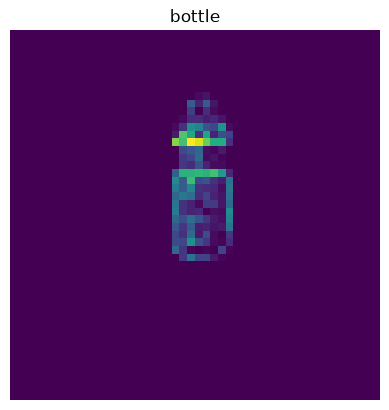

Convolution layer 1


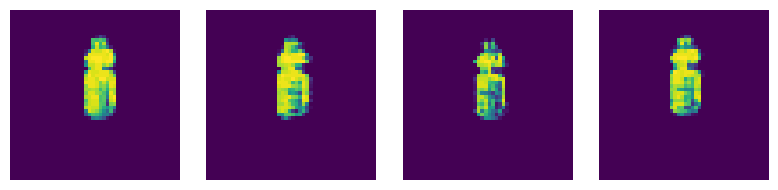

Convolution Layer 2


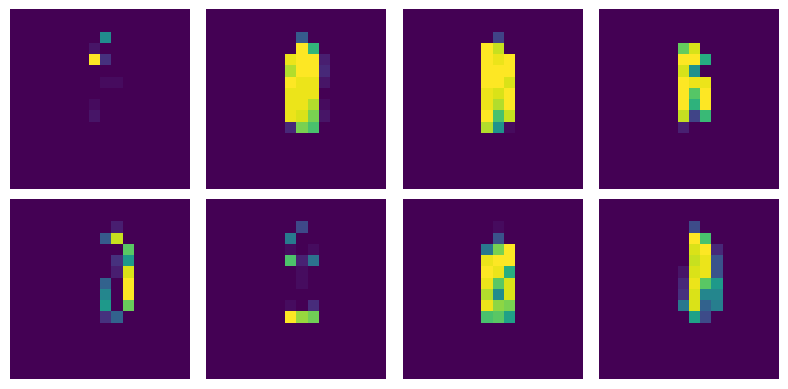

In [95]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

# compute accuracy
preds = logits.argmax(dim=1)
acc = (preds == cats).sum().item()
print(f'Loss {loss.item():.2f} - accuracy {acc / B:.2%}')

idx = 7
label = sample['label'][idx]

plt.imshow(sample['frame'].float()[idx].mean(0))
plt.axis('off')
plt.title(label)
plt.show()

frames = sample['frame'][idx].numpy() * 255
create_gif(frames.astype(np.uint8), f'{label}-{idx}.gif') 

all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    
    frames = fmaps[0][:, idx, counter, :, :].squeeze().cpu().detach().numpy() * 255
    create_gif(frames.astype(np.uint8), f'{label}-{idx}-conv1-{j}.gif') 
    counter += 1
    
plt.axis('off')
plt.tight_layout()
plt.show()

if len(fmaps) > 1:
    
    #print(fmaps[1].shape, torch.where(fmaps[1].mean(dim=0).view(256, -1).argmax()))
    
    all_feature_maps = fmaps[1].sum(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            
            frames = fmaps[1][:, idx, counter, :, :].squeeze().cpu().detach().numpy() * 255
            create_gif(frames.astype(np.uint8), f'{label}-{idx}-conv2-{counter}.gif') 
            
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

torch.Size([35, 5])
(35, 5)


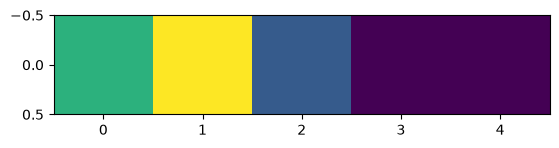

In [96]:
print(spk_out[:, idx, :].shape)
plt.imshow(spk_out.mean(0)[idx].cpu().detach().numpy()[None, :])

frames = spk_out[:, idx, :].cpu().detach().numpy() * 255
print(frames.shape)
create_gif(frames.astype(np.uint8)[:, None], f'{label}-{idx}-out.gif') 

In [83]:
CLASS_LST

['mug', 'bottle', 'coffee_cup']

## Create Hyperparameter Sweep 

In [11]:
sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_accuracy',
        'goal': 'maximize'   
        }
    }

params = {
    'optimizer': {
        'values': ['AdamW']
        },
    'dropout': {
          'values': [0.1, 0.2, 0.3, 0.4, 0.5]
        },
    'surrogate': {
        'values': ['atan', 'fast_sigmoid']
    },
    'lif_threshold': {
        'values': [0.1, 0.3, 0.5]
    },
    'beta': {
        'max': 0.99,
        'min': 0.9,
        'distribution': 'uniform'
    },
    'learning_rate': {
          'max': 0.01,
          'min': 0.0005,
          'distribution': 'uniform'
        },
    'epochs': {
        'value': 10
        }
    }

sweep_config['parameters'] = params

def get_dataloaders(batchsize):
    
    T = transforms.Compose([transforms.ToTensor(),
                            transforms.Pad((0, 30, 0, 30)), #left, top, right, bottom
                            transforms.Resize((48, 48), interpolation=transforms.InterpolationMode.BILINEAR)])

    dataset = CaltechDataset(df, transform=T)

    train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
    val_set, test_set = torch.utils.data.random_split(val_set, [int(len(val_set) * 0.8), len(val_set) - int(len(val_set) * 0.8)])
    print('Training samples: ',len(train_set))
    print('Validation samples: ', len(val_set))
    print('Test samples: ', len(test_set))

    train_loader = DataLoader(train_set, batch_size=batchsize, shuffle=True, num_workers=16)
    val_loader = DataLoader(val_set, batch_size=batchsize//2, shuffle=False, num_workers=8)

    return train_loader, val_loader

def train(config=None):
    # Initialize a new wandb run
    with wandb.init(config=config):
        # If called by wandb.agent, as below,
        # this config will be set by Sweep Controller
        config = wandb.config
        
        torch.manual_seed(RANDOM_SEED)

        train_loader, val_loader = get_dataloaders(BATCH_SIZE)

        # surrogate gradient
        spike_grad = getattr(surrogate, config.surrogate)()
        
        model = SpikingObjectClassifier(img_size=(48, 48), n_classes=257, spike_grad=spike_grad, 
                                        dropout=config.dropout, hidden_channels=4)
        model.to(DEVICE)
        
        loss_fn = nn.CrossEntropyLoss() 
        optimizer = getattr(torch.optim, config.optimizer)(model.parameters(), lr=config.learning_rate)
        
        for epoch in range(config.epochs):
    
            train_loss = []
            train_accuracy = []
            
            model.train()

            for batch_idx, batch in enumerate(train_loader):
                optimizer.zero_grad()
                
                B, T, H, W = batch['frame'].shape
                frames = batch['frame'].float().to(DEVICE)
                cats = batch['cat'].to(DEVICE) 
                
                spk_out, mem_rec, _ = model(frames)
        
                logits = spk_out.sum(0) # [B,C]
                probs = torch.softmax(logits, dim=1)
                loss = loss_fn(probs, cats)
        
                loss.backward()
                optimizer.step()

                # log train loss 
                train_loss.append(loss.item())

                # compute train accuracy
                preds = logits.argmax(dim=1)
                acc = (preds == cats).sum().item()
                train_accuracy.append(acc / B)

                
            # Validation
            model.eval()
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for batch_idx, batch in enumerate(val_loader):

                    B, T, H, W = batch['frame'].shape
                    frames = batch['frame'].float().to(DEVICE)
                    cats = batch['cat'].to(DEVICE) 

                    spk_out, mem_rec, _ = model(frames)

                    logits = spk_out.sum(0) # [B,C]
                    probs = torch.softmax(logits, dim=1)
                    loss = loss_fn(probs, cats)
        
                    val_loss.append(loss.item())
                    
                    # compute validation accuracy
                    preds = logits.argmax(dim=1)
                    acc = (preds == cats).sum().item()
                    val_accuracy.append(acc / B)
                        
            # log metrics to wandb
            wandb.log({'train_loss': np.mean(train_loss), 'train_accuracy': np.mean(train_accuracy),
                       'val_loss': np.mean(val_loss), 'val_accuracy': np.mean(val_accuracy), 'epoch': epoch}) 
            """
            # log feature maps from last validation batch
            for idx, maps in enumerate(fmaps): 
                maps = maps.sum(dim=0)
                best_idx = maps.view(maps.shape[0], -1).sum(dim=-1).argmax() # best sample 
                i = np.random.choice(maps[best_idx].shape[0]) # pick random feature map 
                bmap = maps[best_idx][i].squeeze().cpu().detach().numpy()
                wandb_images = wandb.Image(bmap, caption=f'Feature Maps - Layer {2+idx}: {bmap.shape[-1]}x{bmap.shape[-1]}')
                wandb.log({f'Feature Maps {idx}': wandb_images})
            """

In [12]:
RANDOM_SEED = 7
BATCH_SIZE = 1024
        
seed_everything(RANDOM_SEED)

sweep_id = wandb.sweep(sweep_config, project="RoDeO")
wandb.agent(sweep_id, train, count=20)

Global seed set to 7


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.


Create sweep with ID: abzpxlpc
Sweep URL: https://wandb.ai/apenzko/RoDeO/sweeps/abzpxlpc


wandb: Agent Starting Run: pt1eb8va with config:
wandb: 	beta: 0.9288555721874286
wandb: 	dropout: 0.1
wandb: 	epochs: 10
wandb: 	learning_rate: 0.005182677324193599
wandb: 	lif_threshold: 0.1
wandb: 	optimizer: AdamW
wandb: 	surrogate: fast_sigmoid
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.
wandb: Currently logged in as: apenzko to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training samples:  24485
Validation samples:  4897
Test samples:  1225


...

Training samples:  24485
Validation samples:  4897
Test samples:  1225


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▆▆▇▇▇▇██
train_loss,█▆▄▃▃▂▂▂▁▁
val_accuracy,▁▅▇▆▇▇▇███
val_loss,█▄▃▂▂▂▁▁▁▁
epoch,9
train_accuracy,0.11794
train_loss,5.43948
val_accuracy,0.10957
val_loss,5.44828


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jwe0mthz with config:
wandb: 	beta: 0.9044726651423814
wandb: 	dropout: 0.5
wandb: 	epochs: 10
wandb: 	learning_rate: 0.007391856881999337
wandb: 	lif_threshold: 0.5
wandb: 	optimizer: AdamW
wandb: 	surrogate: atan
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/penzkofer/.netrc.


Training samples:  24485
Validation samples:  4897
Test samples:  1225


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▄▆▆▇▇▇▇██
train_loss,█▅▃▃▂▂▂▂▁▁
val_accuracy,▁▃▅▄█▅▇▆▇█
val_loss,█▆▅▅▂▃▂▂▁▁
epoch,9
train_accuracy,0.10367
train_loss,5.45345
val_accuracy,0.10092
val_loss,5.4554


## Check feature maps

In [22]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
#frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

In [23]:
idx = 0
test_loss = nn.CrossEntropyLoss()
#input = torch.randn(3, 5, requires_grad=True)
#target = torch.randn(3, 5).softmax(dim=1)
output = test_loss(probs[idx], cats[idx])
print(output)
#output.backward()

tensor(2.5405, device='cuda:0', grad_fn=<NllLossBackward0>)


In [24]:
spk_out.sum(dim=0)[idx, :].argmax(), cats[idx]

(tensor(2, device='cuda:0'), tensor(5, device='cuda:0'))

In [25]:
#for idx in range(10):
idx = 2
print(spk_out.sum(dim=0)[idx].cpu().detach().numpy(), spk_out.sum(dim=0)[idx].argmax(), cats[idx])

[ 0.  0.  0. 28.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.] tensor(3, device='cuda:0') tensor(11, device='cuda:0')


In [26]:
for idx, maps in enumerate(fmaps):
    maps = maps.sum(dim=0)
    best_idx = maps.view(maps.shape[0], -1).sum(dim=-1).argmax() # best sample 
    i = np.random.choice(maps[best_idx].shape[0])
    best_map = maps[best_idx][i].squeeze().cpu().detach().numpy()
    print(maps.shape, maps[best_idx].shape, i, best_map.shape)

torch.Size([32, 32, 48, 48]) torch.Size([32, 48, 48]) 15 (48, 48)
torch.Size([32, 64, 24, 24]) torch.Size([64, 24, 24]) 4 (24, 24)
torch.Size([32, 64, 12, 12]) torch.Size([64, 12, 12]) 25 (12, 12)


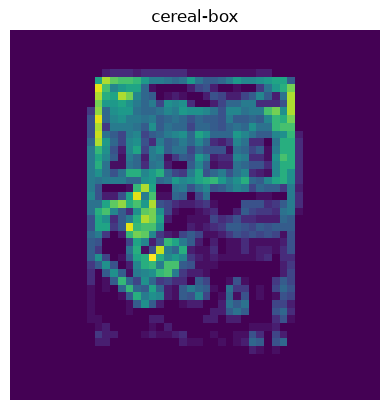

Convolution layer 1


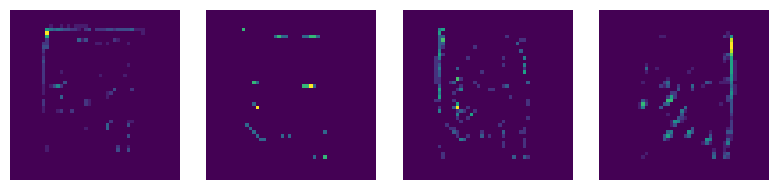

torch.Size([35, 32, 64, 24, 24]) (tensor([0], device='cuda:0'),)
Convolution Layer 2


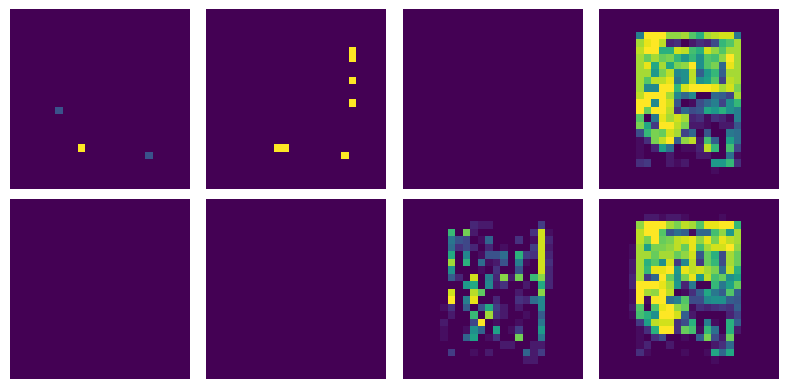

tensor(0, device='cuda:0') tensor(4, device='cuda:0')


In [27]:
model.eval()
sample = next(iter(val_loader))

B, T, H, W = sample['frame'].shape
#frames = sample['frame'].float().view(T, B, -1).to(DEVICE)
frames = sample['frame'].float().to(DEVICE)
cats = sample['cat'].to(DEVICE) 

spk_out, mem_rec, fmaps = model(frames)
logits = spk_out.sum(0) # [B,C]

# compute loss
probs = torch.softmax(logits, dim=1)
loss = loss_fn(probs, cats)

idx = 1
label = sample['label'][idx]

plt.imshow(sample['frame'].float()[idx].mean(0))
plt.axis('off')
plt.title(label)
plt.show()

all_feature_maps = fmaps[0].mean(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.mean(torch.stack(cur_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()
#all_feature_maps = torch.sum(torch.stack(mem_rec), axis=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

print('Convolution layer 1')
fig, axs = plt.subplots(1, 4, sharey=True, sharex=True, figsize=(8, 2))
counter = 0
for j in range(4):
    #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
    axs[j].imshow(all_feature_maps[counter])
    axs[j].axis('off')
    counter += 1
        
plt.axis('off')
plt.tight_layout()
plt.show()


if len(fmaps) > 1:
    
    print(fmaps[1].shape, torch.where(fmaps[1].mean(dim=0).view(256, -1).argmax()))
    
    all_feature_maps = fmaps[1].sum(dim=0)[idx, :, :, :].squeeze().cpu().detach().numpy()

    print('Convolution Layer 2')

    fig, axs = plt.subplots(2, 4, sharey=True, sharex=True, figsize=(8, 4))
    counter = 0
    for i in range(2):
        for j in range(4):
            #print(all_feature_maps[counter].min(), all_feature_maps[counter].max())
            axs[i, j].imshow(all_feature_maps[counter])
            axs[i, j].axis('off')
            counter += 1

    plt.axis('off')
    plt.tight_layout()
    plt.show()

print(spk_out.sum(dim=0)[idx].argmax(), cats[idx])

(tensor([0., 6., 0., 1., 0., 6., 3., 4., 7., 0., 1., 0., 4., 0., 6.],
        device='cuda:0', grad_fn=<SelectBackward0>),
 tensor(8, device='cuda:0'),
 tensor(9, device='cuda:0'))